手作りサンプル
nodes: 6
edges: 8
components: 1
rank: 5
matroidness: 0.625
cycle_basis_count: 3
cycle_redundancy: 3
avg_cycle_length: 3.3333333333333335
max_cycle_length: 4
spanning_tree_count: 30
Erdos-Renyi
nodes: 20
edges: 28
components: 2
rank: 18
matroidness: 0.6428571428571429
cycle_basis_count: 10
cycle_redundancy: 10
avg_cycle_length: 4.4
max_cycle_length: 6
spanning_tree_count: 0
Random Tree
nodes: 20
edges: 19
components: 1
rank: 19
matroidness: 1.0
cycle_basis_count: 0
cycle_redundancy: 0
avg_cycle_length: 0
max_cycle_length: 0
spanning_tree_count: 1
Complete Graph
nodes: 20
edges: 190
components: 1
rank: 19
matroidness: 0.1
cycle_basis_count: 171
cycle_redundancy: 171
avg_cycle_length: 3.0
max_cycle_length: 3
spanning_tree_count: 262143999999999094030336
Barabasi-Albert
nodes: 20
edges: 36
components: 1
rank: 19
matroidness: 0.5277777777777778
cycle_basis_count: 17
cycle_redundancy: 17
avg_cycle_length: 3.764705882352941
max_cycle_length: 7
spanning_tree_count: 27462655
Watts-Strog

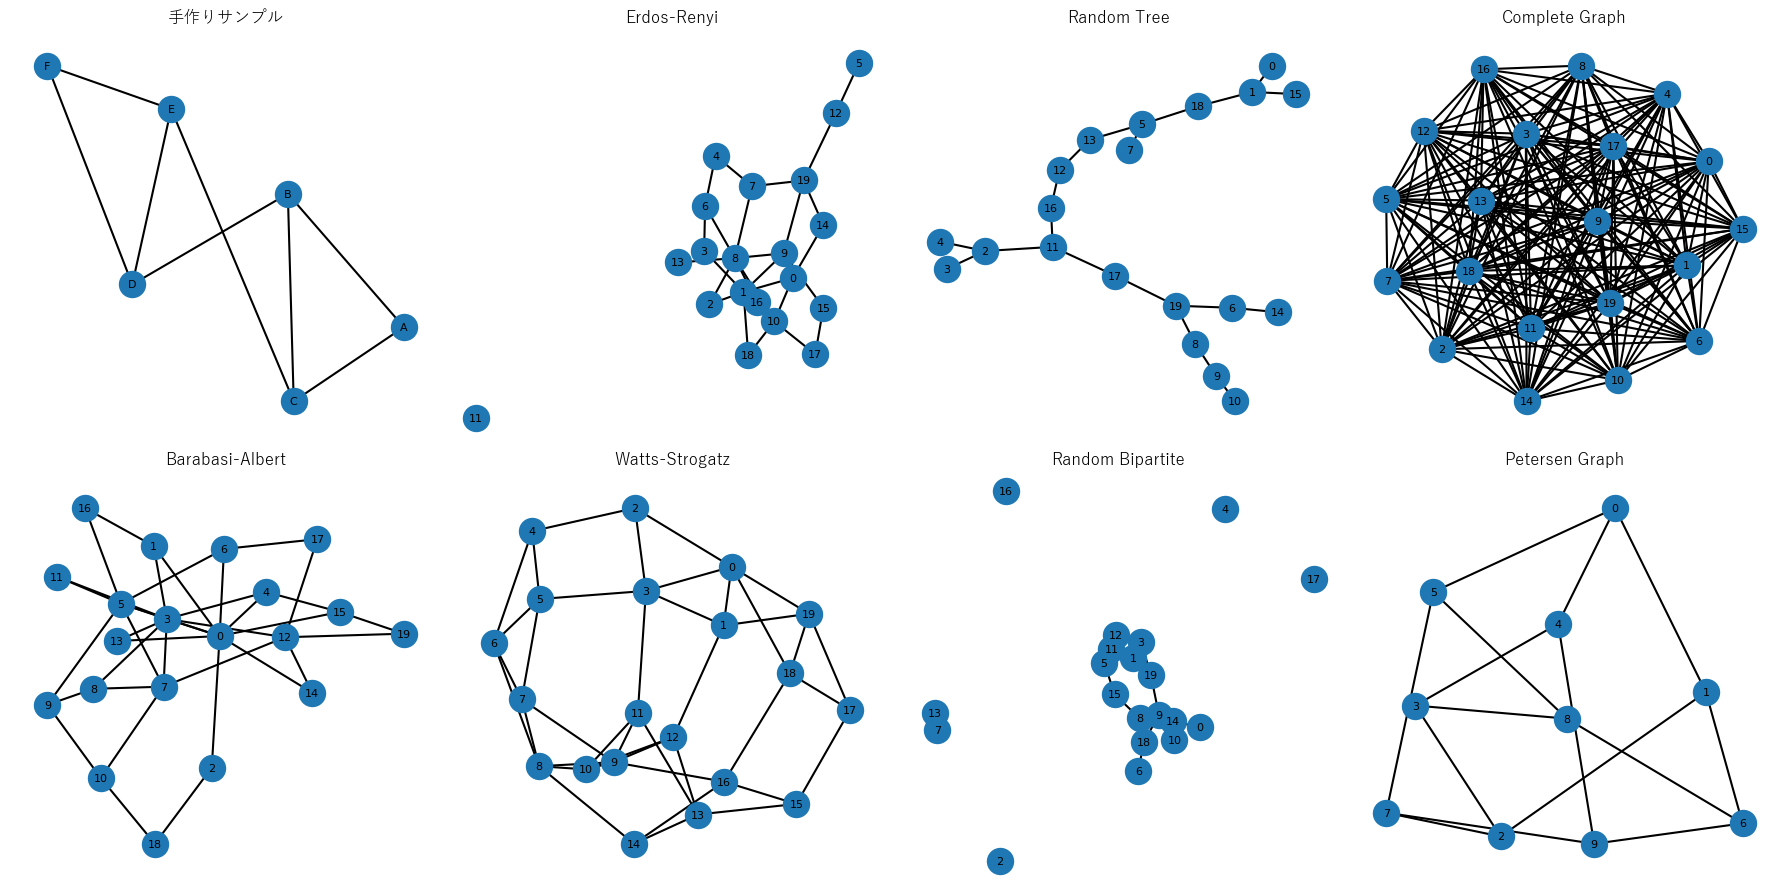

グラフ画像保存: matroid_graph_results\sample_graphs.png


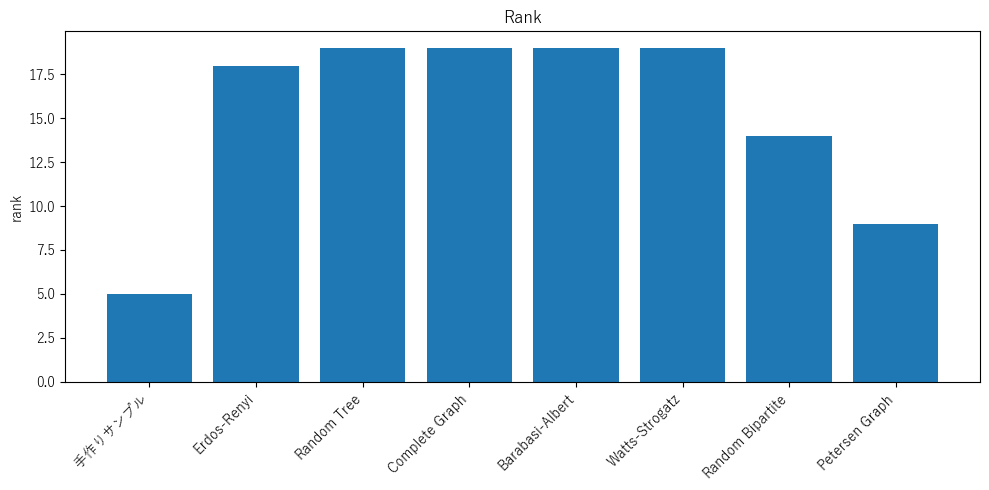

保存: matroid_graph_results\rank.png


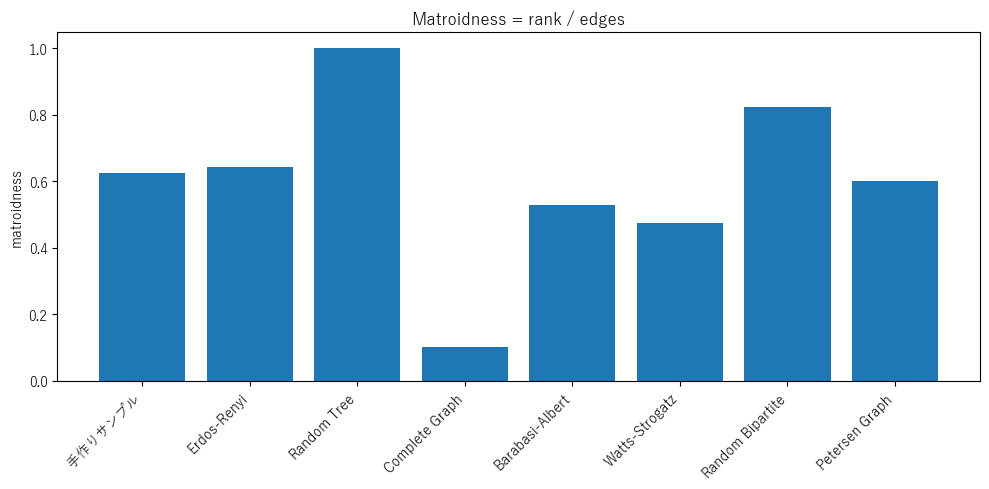

保存: matroid_graph_results\matroidness.png


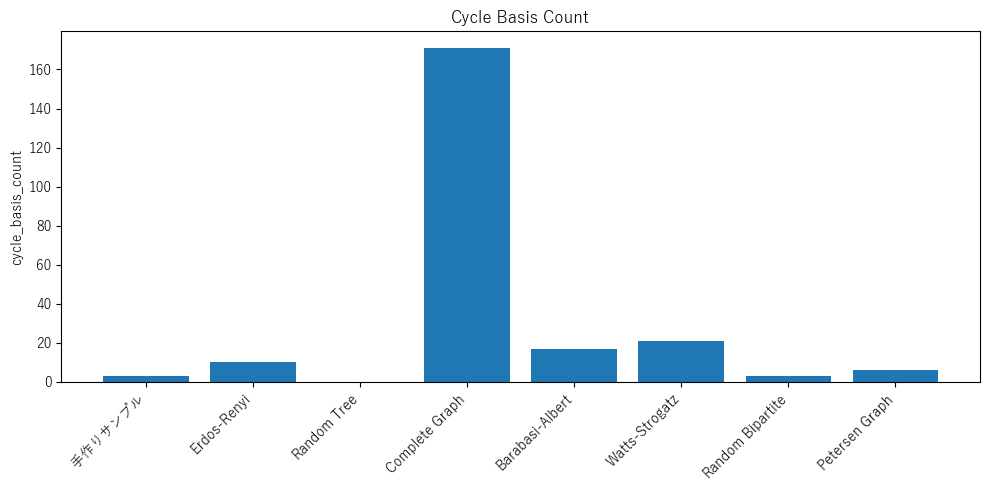

保存: matroid_graph_results\cycle_basis_count.png


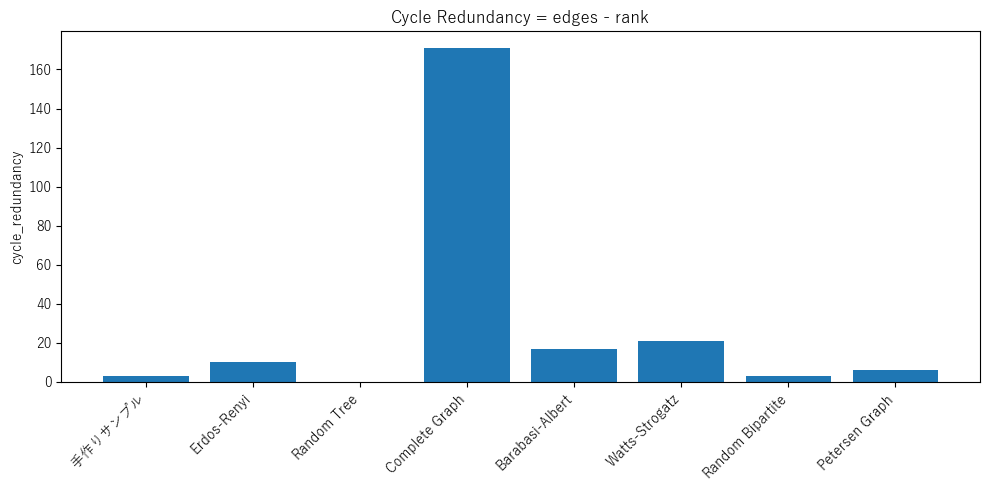

保存: matroid_graph_results\cycle_redundancy.png


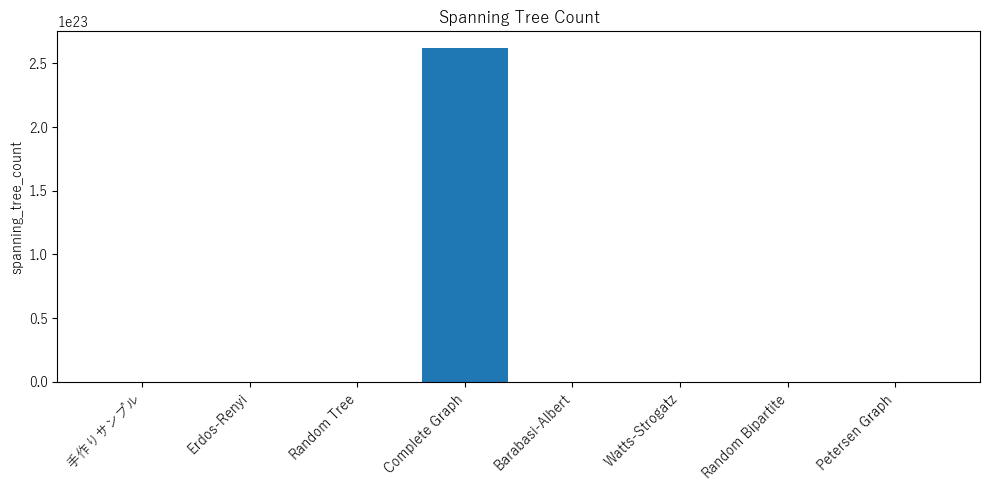

保存: matroid_graph_results\spanning_tree_count.png

ランダムグラフ実験CSV保存: matroid_graph_results\random_graph_experiment.csv
要約CSV保存: matroid_graph_results\random_graph_summary.csv


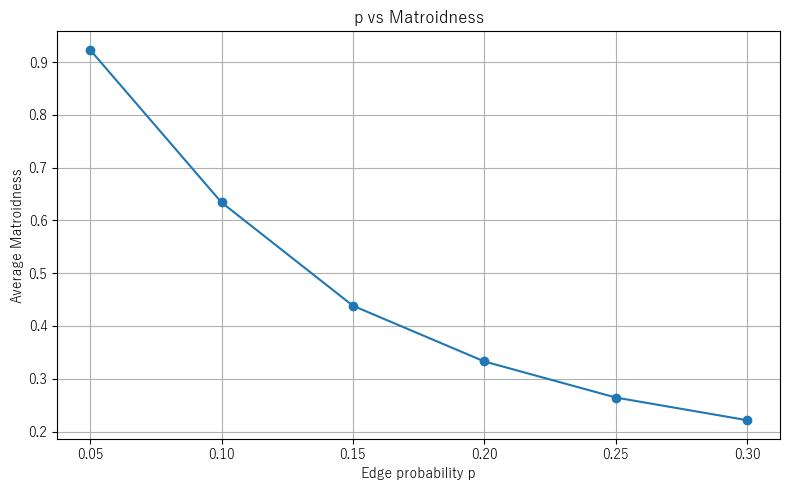

Matroidness画像保存: matroid_graph_results\p_vs_matroidness.png


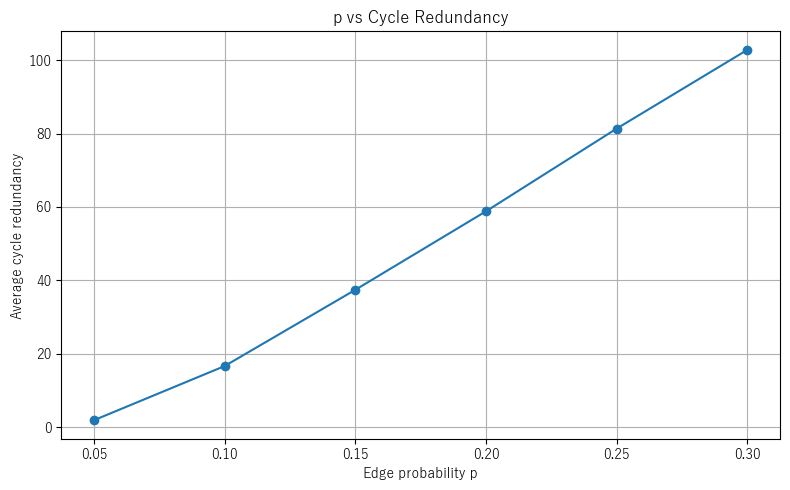

閉路冗長性画像保存: matroid_graph_results\p_vs_cycle_redundancy.png

完了しました。
出力フォルダ: matroid_graph_results

主な出力ファイル:
 - graph_matroid_metrics.csv
 - sample_graphs.png
 - rank.png
 - matroidness.png
 - cycle_basis_count.png
 - cycle_redundancy.png
 - spanning_tree_count.png
 - random_graph_experiment.csv
 - random_graph_summary.csv
 - p_vs_matroidness.png
 - p_vs_cycle_redundancy.png


In [3]:
import os
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "Yu Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# =========================
# 設定
# =========================

OUT_DIR = "matroid_graph_results"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# =========================
# 基本関数
# =========================

def safe_random_tree(n, seed=None):
    """
    NetworkX 3.4以降では random_tree が削除されたため、
    random_labeled_tree を使用する。
    """
    if hasattr(nx, "random_labeled_tree"):
        return nx.random_labeled_tree(n=n, seed=seed)
    else:
        return nx.random_tree(n=n, seed=seed)


def count_spanning_trees(G):
    """
    Kirchhoffの行列木定理による全域木数。
    非連結グラフでは 0。
    """
    if G.number_of_nodes() == 0:
        return 0

    if not nx.is_connected(G):
        return 0

    L = nx.laplacian_matrix(G).toarray()
    cofactor = L[:-1, :-1]

    det = np.linalg.det(cofactor)
    return int(round(det))


def graph_matroid_metrics(G, name="graph"):
    """
    グラフマトロイドの基本指標を計算する。
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    components = nx.number_connected_components(G)

    # グラフマトロイドのランク
    rank = n - components

    # 閉路基底
    cycles = nx.cycle_basis(G)
    cycle_basis_count = len(cycles)
    cycle_lengths = [len(c) for c in cycles]

    # Matroidness
    matroidness = rank / m if m > 0 else 0

    # 閉路余剰度
    cycle_redundancy = m - rank

    # 全域木数
    spanning_trees = count_spanning_trees(G)

    return {
        "name": name,
        "nodes": n,
        "edges": m,
        "components": components,
        "rank": rank,
        "matroidness": matroidness,
        "cycle_basis_count": cycle_basis_count,
        "cycle_redundancy": cycle_redundancy,
        "avg_cycle_length": np.mean(cycle_lengths) if cycle_lengths else 0,
        "max_cycle_length": max(cycle_lengths) if cycle_lengths else 0,
        "spanning_tree_count": spanning_trees,
    }


def print_metrics(metrics):
    print("=" * 60)
    print(metrics["name"])
    for k, v in metrics.items():
        if k != "name":
            print(f"{k}: {v}")


# =========================
# サンプルグラフ作成
# =========================

graphs = []

# 1. 手作りサンプル
G_sample = nx.Graph()
G_sample.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E"),
    ("D", "F"),
    ("E", "F"),
])
graphs.append(("手作りサンプル", G_sample))

# 2. Erdős–Rényi ランダムグラフ
G_er = nx.erdos_renyi_graph(n=20, p=0.15, seed=1)
graphs.append(("Erdos-Renyi", G_er))

# 3. ランダム木
G_tree = safe_random_tree(n=20, seed=2)
graphs.append(("Random Tree", G_tree))

# 4. 完全グラフ
G_complete = nx.complete_graph(20)
graphs.append(("Complete Graph", G_complete))

# 5. Barabási–Albert スケールフリー
G_ba = nx.barabasi_albert_graph(n=20, m=2, seed=3)
graphs.append(("Barabasi-Albert", G_ba))

# 6. Watts–Strogatz スモールワールド
G_ws = nx.watts_strogatz_graph(n=20, k=4, p=0.2, seed=4)
graphs.append(("Watts-Strogatz", G_ws))

# 7. 二部グラフ
G_bip = nx.bipartite.random_graph(n=10, m=10, p=0.2, seed=5)
graphs.append(("Random Bipartite", G_bip))

# 8. ペテルセングラフ
G_petersen = nx.petersen_graph()
graphs.append(("Petersen Graph", G_petersen))


# =========================
# 指標計算
# =========================

results = []

for name, G in graphs:
    metrics = graph_matroid_metrics(G, name)
    results.append(metrics)
    print_metrics(metrics)

df = pd.DataFrame(results)

csv_path = os.path.join(OUT_DIR, "graph_matroid_metrics.csv")
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("\nCSV保存:", csv_path)


# =========================
# グラフ描画
# =========================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (name, G) in zip(axes, graphs):
    pos = nx.spring_layout(G, seed=RANDOM_SEED)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=350)
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()

graph_png_path = os.path.join(OUT_DIR, "sample_graphs.png")
plt.savefig(graph_png_path, dpi=300)
plt.show()

print("グラフ画像保存:", graph_png_path)


# =========================
# 指標比較グラフ
# =========================

plot_items = [
    ("rank", "Rank"),
    ("matroidness", "Matroidness = rank / edges"),
    ("cycle_basis_count", "Cycle Basis Count"),
    ("cycle_redundancy", "Cycle Redundancy = edges - rank"),
    ("spanning_tree_count", "Spanning Tree Count"),
]

for col, title in plot_items:
    plt.figure(figsize=(10, 5))
    plt.bar(df["name"], df[col])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.ylabel(col)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"{col}.png")
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("保存:", out_path)


# =========================
# ランダムグラフを多数生成して統計
# =========================

def random_graph_experiment(
    n=30,
    p_values=(0.05, 0.10, 0.15, 0.20, 0.25, 0.30),
    trials=50
):
    rows = []

    for p in p_values:
        for t in range(trials):
            G = nx.erdos_renyi_graph(n=n, p=p, seed=1000 + t)
            metrics = graph_matroid_metrics(G, name=f"G(n={n}, p={p})")
            metrics["p"] = p
            metrics["trial"] = t
            rows.append(metrics)

    return pd.DataFrame(rows)


df_exp = random_graph_experiment()

exp_csv_path = os.path.join(OUT_DIR, "random_graph_experiment.csv")
df_exp.to_csv(exp_csv_path, index=False, encoding="utf-8-sig")

print("\nランダムグラフ実験CSV保存:", exp_csv_path)


# =========================
# p と Matroidness の関係
# =========================

summary = df_exp.groupby("p").agg({
    "edges": "mean",
    "rank": "mean",
    "matroidness": "mean",
    "cycle_basis_count": "mean",
    "cycle_redundancy": "mean",
}).reset_index()

summary_csv_path = os.path.join(OUT_DIR, "random_graph_summary.csv")
summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

print("要約CSV保存:", summary_csv_path)

plt.figure(figsize=(8, 5))
plt.plot(summary["p"], summary["matroidness"], marker="o")
plt.title("p vs Matroidness")
plt.xlabel("Edge probability p")
plt.ylabel("Average Matroidness")
plt.grid(True)
plt.tight_layout()

matroidness_png_path = os.path.join(OUT_DIR, "p_vs_matroidness.png")
plt.savefig(matroidness_png_path, dpi=300)
plt.show()

print("Matroidness画像保存:", matroidness_png_path)


# =========================
# p と 閉路冗長性
# =========================

plt.figure(figsize=(8, 5))
plt.plot(summary["p"], summary["cycle_redundancy"], marker="o")
plt.title("p vs Cycle Redundancy")
plt.xlabel("Edge probability p")
plt.ylabel("Average cycle redundancy")
plt.grid(True)
plt.tight_layout()

redundancy_png_path = os.path.join(OUT_DIR, "p_vs_cycle_redundancy.png")
plt.savefig(redundancy_png_path, dpi=300)
plt.show()

print("閉路冗長性画像保存:", redundancy_png_path)


# =========================
# 最終表示
# =========================

print("\n完了しました。")
print("出力フォルダ:", OUT_DIR)
print("\n主な出力ファイル:")
print(" - graph_matroid_metrics.csv")
print(" - sample_graphs.png")
print(" - rank.png")
print(" - matroidness.png")
print(" - cycle_basis_count.png")
print(" - cycle_redundancy.png")
print(" - spanning_tree_count.png")
print(" - random_graph_experiment.csv")
print(" - random_graph_summary.csv")
print(" - p_vs_matroidness.png")
print(" - p_vs_cycle_redundancy.png")